<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [88]:
import torch
import torch.nn as nn
import timm
import numpy as np
import pandas as pd
import albumentations as A

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from albumentations.pytorch.transforms import ToTensorV2

import math
from functools import partial
from collections import Counter, defaultdict

import io
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.ops import nms, box_iou
from torchvision.models.detection.anchor_utils import AnchorGenerator

from torchmetrics.detection import MeanAveragePrecision

### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [89]:
splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

Создаем датасет для предобработки данных

In [90]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        df_objects = pd.json_normalize(dataframe['objects'])[["bbox", "category"]]
        df_images = pd.json_normalize(dataframe['image'])[["bytes"]]
        self.data = dataframe[["image_id"]].join(df_objects).join(df_images)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        """Загружаем данные и разметку для объекта с индексом `idx`.

        labels: List[int] Набор классов для каждого ббокса,
        boxes: List[List[int]] Набор ббоксов в формате (x_min, y_min, w, h).
        """
        row = self.data.iloc[idx]
        image = Image.open(io.BytesIO(row["bytes"]))
        image = np.array(image)

        target = {}
        target["image_id"] = row["image_id"]

        labels = [row["category"]] if isinstance(row["category"], int) else row['category']
        # Вычитаем единицу чтобы классы начинались с нуля
        labels = [label - 1 for label in labels]
        boxes = row['bbox'].tolist()

        if self.transform is not None:
            transformed = self.transform(image=image, bboxes=boxes, labels=labels)
            image, boxes, labels = transformed["image"], transformed["bboxes"], transformed["labels"]
        else:
            image = transforms.ToTensor()(image)

        target['boxes'] = torch.tensor(np.array(boxes), dtype=torch.float32)
        target['labels'] = torch.tensor(labels, dtype=torch.int64)
        return image, target

def collate_fn(batch):
    batch = tuple(zip(*batch))
    images = torch.stack(batch[0])
    return images, batch[1]

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [91]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        # Добавляй сюда свои аугментации при необходимости!
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    # Раскомментируй, если аугментации изменяют ббоксы.
    # Не забудь указать верный формат для ббоксов.
    # bbox_params=A.BboxParams(format='coco', label_fields=['labels'])
)

test_transform = A.Compose(
    [
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ]
)

Не забываем инициализировать наш датасет

In [92]:
train_dataset = HaloDataset(df_train, transform=train_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать.

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

In [93]:
class Backbone(nn.Module):
    def __init__(self, model_name="efficientnet_b5", out_indices=(-1, -2, -3), k=3):
        """
        Инициализация бэкбона.

        :param model_name: Имя модели из timm.
        :param out_indices: Индексы выходов, которые нужно вернуть.
        :param k: Количество последних слоев, которые нужно разморозить.
        """
        super(Backbone, self).__init__()
        self.out_indices = out_indices
        
        # Создание модели с использованием timm
        self.backbone = timm.create_model(model_name, pretrained=True, features_only=True, out_indices=self.out_indices)

        # Замораживаем все слои
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Размораживаем последние k слоев
        self.unfreeze_layers(k)

    def unfreeze_layers(self, k):
        """
        Размораживает последние k слоев модели.

        :param k: Количество слоев для разморозки.
        """
        layers = list(self.backbone.children())

        # Убедитесь, что k не превышает количество слоев
        if k > len(layers):
            k = len(layers)
            print(f'k задано больше, чем количество слоев модели, размораживаем все слои. k = {k}')

        # Размораживаем последние k слоев
        for layer in layers[-k:]:
            for param in layer.parameters():
                param.requires_grad = True

    def forward(self, x):
        """
        Прямой проход через бэкбон.

        :param x: Входные данные (изображение).
        :return: Извлеченные признаки.
        """
        features = self.backbone(x)
        # Возвращаем только те выходы, которые указаны в out_indices
        return [features[i] for i in self.out_indices]

### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

In [94]:
class FPN(nn.Module):
    def __init__(self, in_channels=[256, 512, 1024, 2048], out_channels=256):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # Lateral connections (1x1 conv for each level)
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(ch, out_channels, kernel_size=1)
            for ch in in_channels
        ])
        
        # Output convolutions (3x3 conv after fusion)
        self.output_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in range(len(in_channels))
        ])
        
        # Top-down pathway upsample
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        
    def forward(self, features):
        # features from backbone: low to high resolution
        # Build lateral outputs
        lateral_outputs = [lateral_conv(feat) for lateral_conv, feat in zip(self.lateral_convs, features)]
        
        # Top-down pathway
        fpn_features = []
        last_feature = lateral_outputs[-1]
        fpn_features.append(last_feature)
        
        for i in range(len(lateral_outputs) - 2, -1, -1):
            upsampled = self.upsample(last_feature)
            # Handle size mismatches
            if upsampled.shape[2:] != lateral_outputs[i].shape[2:]:
                upsampled = F.interpolate(upsampled, size=lateral_outputs[i].shape[2:], mode='nearest')
            last_feature = upsampled + lateral_outputs[i]
            fpn_features.insert(0, last_feature)
        
        # Apply output convolutions
        output_features = [conv(feat) for conv, feat in zip(self.output_convs, fpn_features)]
        
        return output_features

### Head [1 балл]

В качестве шеи можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будте внимательны при расчете лосса!

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

In [95]:
class DecoupledHead(nn.Module):
    def __init__(self, in_channels, num_classes, num_anchors):
        """
        Инициализация Decoupled Head для YOLOX.

        :param in_channels: Количество входных каналов.
        :param num_classes: Число классов для классификации.
        :param num_anchors: Число якорей.
        """
        super(DecoupledHead, self).__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors

        # Полносвязные слои для классификации
        self.cls_layer = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, num_classes * num_anchors, kernel_size=1, stride=1)
        )

        # Полносвязные слои для регрессии
        self.reg_layer = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, 4 * num_anchors, kernel_size=1, stride=1)  # 4 координаты для bbox
        )

    def forward(self, x):
        """
        Прямой проход через Decoupled Head.

        :param x: Входные данные (признаки из Neck).
        :return: Классификационные и регрессионные выходы.
        """
        cls_output = self.cls_layer(x)  # Выход для классов
        reg_output = self.reg_layer(x)  # Выход для регрессии

        # Применяем активацию для классификационного выхода
        cls_output = torch.sigmoid(cls_output)  # Применяем Sigmoid для вероятностей классов

        return cls_output, reg_output

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

In [96]:
class Detector(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", num_classes=4, out_channels=128,
                 anchor_sizes=((32, 64), (64, 128), (128, 256)), 
                 anchor_ratios=((0.5, 1.0, 2.0),) * 3, 
                 input_size=(640, 640)):
        super(Detector, self).__init__()
        self.num_classes = num_classes
        self.backbone = Backbone(model_name=backbone_name, k=5)
        
        in_channels_list = self.backbone.backbone.feature_info.channels()
        
        self.fpn = FPN(in_channels=in_channels_list, out_channels=out_channels)
        
        num_fpn_levels = len(in_channels_list)
        num_anchors_per_level = len(anchor_sizes[0]) * len(anchor_ratios[0])
        self.heads = nn.ModuleList([
            DecoupledHead(in_channels=out_channels, num_classes=num_classes, num_anchors=num_anchors_per_level)
            for _ in range(num_fpn_levels)
        ])
        
        # Генерируем якоря для каждого уровня FPN
        all_anchors = []
        all_anchor_centers = []
        all_anchor_sizes = []
        
        for level_idx in range(num_fpn_levels):
            stride = self.backbone.backbone.feature_info.reduction()[level_idx]
            grid_sizes = [[input_size[0] // stride, input_size[1] // stride]]
            
            anchor_generator = AnchorGenerator(
                sizes=(anchor_sizes[level_idx],), 
                aspect_ratios=(anchor_ratios[level_idx],)
            )
            
            anchors = anchor_generator.grid_anchors(grid_sizes, strides=[[stride, stride]])
            anchors = torch.stack(anchors, dim=0)
            
            anchor_centers = (anchors[:, :, :2] + anchors[:, :, 2:]) / 2
            anchor_sizes_tensor = (anchors[:, :, 2:] - anchors[:, :, :2])
            
            all_anchors.append(anchors)
            all_anchor_centers.append(anchor_centers)
            all_anchor_sizes.append(anchor_sizes_tensor)
        
        self.register_buffer("anchors", torch.cat(all_anchors, dim=1))
        self.register_buffer("anchor_centers", torch.cat(all_anchor_centers, dim=1))
        self.register_buffer("anchor_sizes", torch.cat(all_anchor_sizes, dim=1))
        
    def forward(self, x):
        features = self.backbone(x)
        neck_features = self.fpn(features)
        
        all_cls_logits = []
        all_bbox_preds = []
        
        for feat, head in zip(neck_features, self.heads):
            cls_logits, bbox_preds = head(feat)
            
            N = x.shape[0]
            cls_logits = cls_logits.permute(0, 2, 3, 1).contiguous()
            cls_logits = cls_logits.view(N, -1, self.num_classes)
            
            bbox_preds = bbox_preds.permute(0, 2, 3, 1).contiguous()
            bbox_preds = bbox_preds.view(N, -1, 4)
            
            all_cls_logits.append(cls_logits)
            all_bbox_preds.append(bbox_preds)
        
        cls_logits = torch.cat(all_cls_logits, dim=1)
        bbox_preds = torch.cat(all_bbox_preds, dim=1)
        
        bbox_offsets = bbox_preds[:, :, :4]
        
        if self.training:
            # Возвращаем только 2 компонента
            return bbox_offsets, cls_logits
        
        bboxes = self.decode_bboxes(bbox_offsets)
        cls_probs = torch.softmax(cls_logits, dim=-1)
        confidence = torch.max(cls_probs, dim=-1)[0]
        return bboxes, confidence, cls_probs

    def decode_bboxes(self, bbox_offsets):
        tx = bbox_offsets[:, :, 0]
        ty = bbox_offsets[:, :, 1]
        tw = bbox_offsets[:, :, 2]
        th = bbox_offsets[:, :, 3]

        center_x = self.anchor_centers[:, :, 0] + torch.sigmoid(tx) * self.anchor_sizes[:, :, 0]
        center_y = self.anchor_centers[:, :, 1] + torch.sigmoid(ty) * self.anchor_sizes[:, :, 1]

        w = torch.exp(tw) * self.anchor_sizes[:, :, 0]
        h = torch.exp(th) * self.anchor_sizes[:, :, 1]

        x_min = center_x - w / 2
        y_min = center_y - h / 2
        return torch.stack([x_min, y_min, w, h], dim=-1)

## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [97]:
def get_target_offset(anchor_box, gt_box):
    """
    Вычисляет целевые смещения для якоря относительно GT ббокса.
    
    Параметры:
    anchor_box: [x_min, y_min, x_max, y_max] - якорь
    gt_box: [x_min, y_min, x_max, y_max] - истинный ббокс
    
    Возвращает:
    Смещения [tx, ty, tw, th] в формате YOLO
    """
    # Центры и размеры якоря
    anchor_w = anchor_box[2] - anchor_box[0]
    anchor_h = anchor_box[3] - anchor_box[1]
    anchor_cx = (anchor_box[0] + anchor_box[2]) / 2
    anchor_cy = (anchor_box[1] + anchor_box[3]) / 2
    
    # Центры и размеры GT
    gt_w = gt_box[2] - gt_box[0]
    gt_h = gt_box[3] - gt_box[1]
    gt_cx = (gt_box[0] + gt_box[2]) / 2
    gt_cy = (gt_box[1] + gt_box[3]) / 2
    
    # Вычисляем смещения по формулам из YOLO
    tx = (gt_cx - anchor_cx) / anchor_w
    ty = (gt_cy - anchor_cy) / anchor_h
    tw = torch.log(gt_w / anchor_w)
    th = torch.log(gt_h / anchor_h)
    
    return torch.stack([tx, ty, tw, th])

In [98]:
def assign_target(anchors, gt_boxes, gt_labels, num_classes, pos_th=0.6, neg_th=0.3):
    """ Для каждого GT находим якоря, которые будут участвовать в расчете лосса """
    num_anchors = anchors.shape[0]
    target_objectness = torch.zeros(num_anchors, device=anchors.device)
    target_offsets = torch.zeros((num_anchors, 4), device=anchors.device)
    target_cls = torch.zeros((num_anchors, num_classes), device=anchors.device)
    
    if gt_boxes.numel() == 0:
        return target_offsets, target_objectness, target_cls
    
    # Переводим GT в формат xyxy
    gt_xyxy = gt_boxes.clone()
    gt_xyxy[:, 2:] = gt_xyxy[:, :2] + gt_xyxy[:, 2:]
    
    ious = box_iou(anchors, gt_xyxy)
    best_iou, best_gt_idx = ious.max(dim=1)
    
    ignore_mask = (best_iou >= neg_th) & (best_iou < pos_th)
    target_objectness[ignore_mask] = -1
    
    pos_mask = best_iou >= pos_th
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]
    
    for pos in pos_indices:
        gt_idx = best_gt_idx[pos]
        gt_box = gt_xyxy[gt_idx]
        anchor_box = anchors[pos]
        
        target_offsets[pos] = get_target_offset(anchor_box, gt_box)
        target_objectness[pos] = 1
        target_cls[pos, gt_labels[gt_idx]] = 1
    
    # Присваиваем предсказание с самым большим IoU для GT без предсказаний
    for gt_idx in range(gt_xyxy.shape[0]):
        if not((target_objectness == 1) & (best_gt_idx == gt_idx)).any():
            best_anchor_idx = torch.argmax(ious[:, gt_idx])
            target_offsets[best_anchor_idx] = get_target_offset(anchors[best_anchor_idx], gt_xyxy[gt_idx])
            target_objectness[best_anchor_idx] = 1
            target_cls[best_anchor_idx, gt_labels[gt_idx]] = 1
    
    return target_offsets, target_objectness, target_cls

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \qquad \qquad y^I_1 = $$
$$x^I_2 = \qquad \qquad y^I_2 = $$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = \qquad \qquad y^c_1 = $$
$$x^c_2 = \qquad \qquad y^c_2 = $$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

$d = $

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [99]:
from torchvision.ops import distance_box_iou_loss

In [100]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)

In [101]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [102]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 1.0243922472000122


In [103]:
def diou_loss(pred_boxes, target_boxes):
    pred_x1 = pred_boxes[..., 0]
    pred_y1 = pred_boxes[..., 1]
    pred_x2 = pred_boxes[..., 2]
    pred_y2 = pred_boxes[..., 3]
    target_x1 = target_boxes[..., 0]
    target_y1 = target_boxes[..., 1]
    target_x2 = target_boxes[..., 2]
    target_y2 = target_boxes[..., 3]

    # Вычисление площади пересечения
    inter_x1 = torch.max(pred_x1, target_x1)
    inter_y1 = torch.max(pred_y1, target_y1)
    inter_x2 = torch.min(pred_x2, target_x2)
    inter_y2 = torch.min(pred_y2, target_y2)

    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)
    
    # Площадь предсказанного и истинного прямоугольников
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    target_area = (target_x2 - target_x1) * (target_y2 - target_y1)

    # Площадь объединения
    union_area = pred_area + target_area - inter_area

    # IoU
    iou = inter_area / union_area  # Добавляем небольшое значение для предотвращения деления на ноль

    # Вычисление центров прямоугольников
    pred_x_center = (pred_x1 + pred_x2) / 2
    pred_y_center = (pred_y1 + pred_y2) / 2
    target_x_center = (target_x1 + target_x2) / 2
    target_y_center = (target_y1 + target_y2) / 2   
    # Расстояние между центрами
    center_distance = ((pred_x_center - target_x_center) ** 2 + (pred_y_center - target_y_center) ** 2) 
    # Вычисление диагонали объединяющего прямоугольника
    enclosing_x1 = torch.min(pred_x1, target_x1)
    enclosing_y1 = torch.min(pred_y1, target_y1)
    enclosing_x2 = torch.max(pred_x2, target_x2)
    enclosing_y2 = torch.max(pred_y2, target_y2)
    enclosing_area =((enclosing_x2 - enclosing_x1) ** 2 + (enclosing_y2 - enclosing_y1) ** 2) 

    # DIoU
    diou = 1 - iou + (center_distance / (enclosing_area))  # Добавляем небольшое значение для предотвращения деления на ноль

    return torch.mean(diou)

In [104]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

In [105]:
class ComputeLoss:
    def __init__(self, bbox_loss=None, cls_loss=None, weight_bbox=5, weight_cls=1):
        self.bbox_loss = nn.SmoothL1Loss() if bbox_loss is None else bbox_loss
        self.cls_loss = nn.BCEWithLogitsLoss() if cls_loss is None else cls_loss
        self.weight_bbox = weight_bbox
        self.weight_cls = weight_cls

    def __call__(self, predicts, targets):
        pred_offsets, pred_cls_logits = predicts  # Теперь только 2 компонента
        target_boxes, target_obj, target_cls = targets
        
        # Находим положительные якоря
        pos_mask = target_obj == 1
        
        if pos_mask.sum() > 0:
            # Локализационный лосс
            loss_bbox = self.bbox_loss(pred_offsets[pos_mask], target_boxes[pos_mask])
            # Классификационный лосс
            loss_cls = self.cls_loss(pred_cls_logits[pos_mask], target_cls[pos_mask])
        else:
            loss_bbox = torch.tensor(0.0, device=pred_offsets.device, requires_grad=True)
            loss_cls = torch.tensor(0.0, device=pred_offsets.device, requires_grad=True)
        
        total_loss = self.weight_bbox * loss_bbox + self.weight_cls * loss_cls
        return total_loss

In [106]:
class Runner:
    def __init__(self, model, compute_loss, optimizer, train_dataloader, assign_target_method, device=None,
                 scheduler=None, assign_target_kwargs=None,
                 val_dataloader=None, val_every=5, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8):
        self.model = model
        self.compute_loss = compute_loss
        self.optimizer = optimizer
        self.train_dataloader = train_dataloader
        assign_target_kwargs = {} if assign_target_kwargs is None else assign_target_kwargs
        self.assign_target_method = partial(assign_target_method, **assign_target_kwargs)
        self.device = "cpu" if device is None else device
        self.scheduler = scheduler

        self.val_dataloader = val_dataloader
        self.val_every = val_every
        self.score_threshold = score_threshold
        self.nms_threshold = nms_threshold
        self.max_boxes_per_cls = max_boxes_per_cls

        self.batch_loss = []
        self.epoch_loss = []
        self.val_metric = []

    def _run_train_epoch(self, dataloader, verbose=True):
        self.model.train()
        batch_loss = []
        
        for images, targets in (pbar := tqdm(dataloader, desc=f"Process train epoch", leave=False)):
            images = images.to(self.device)
            # В режиме обучения модель возвращает (bbox_offsets, cls_logits)
            bbox_offsets, cls_logits = self.model(images)

            anchors = self.model.anchors.view(-1, 4)
            accum_loss = torch.tensor(0.0, device=self.device)
            
            for ix in range(images.shape[0]):
                gt_boxes = targets[ix]['boxes'].to(self.device)
                gt_labels = targets[ix]['labels'].to(self.device)
                
                # Получаем таргеты
                assigned_targets = self.assign_target_method(anchors, gt_boxes, gt_labels,
                                                             num_classes=self.model.num_classes)
                
                # Предсказания для этого изображения
                pred_offsets = bbox_offsets[ix]
                pred_cls = cls_logits[ix]
                
                # Считаем лосс
                loss = self.compute_loss((pred_offsets, pred_cls), assigned_targets)
                accum_loss = accum_loss + loss
            
            accum_loss = accum_loss / images.shape[0]
            batch_loss.append(accum_loss.detach().item())

            # Backward pass
            self.optimizer.zero_grad()
            accum_loss.backward()
            self.optimizer.step()
            
            if verbose:
                pbar.set_description(f"Current batch loss: {batch_loss[-1]:.4f}")
                
        return batch_loss

    def train(self, num_epochs=10, verbose=True):
        val_desc = ""
        for epoch in (epoch_pbar := tqdm(range(1, num_epochs+1), desc="Train epoch", total=num_epochs)):
            loss = self._run_train_epoch(self.train_dataloader, verbose=verbose)
            self.batch_loss.extend(loss)
            self.epoch_loss.append(np.mean(self.batch_loss[-len(self.train_dataloader):]))

            if self.val_dataloader is not None and epoch % self.val_every == 0:
                val_metric = self.validate()
                self.val_metric.append(val_metric)
                val_desc = f" Val {val_metric:.4f}"

            if verbose:
                epoch_pbar.set_description(f"Last epoch loss: Train {self.epoch_loss[-1]:.4f}" + val_desc)
                
            if self.scheduler is not None:
                self.scheduler.step()

    @torch.no_grad()
    def validate(self, dataloader=None):
        self.model.eval()
        dataloader = self.val_dataloader if dataloader is None else dataloader
        metric = MeanAveragePrecision(box_format="xywh", iou_type="bbox")
        
        for images, targets in tqdm(dataloader, desc="Running validation", leave=False):
            images = images.to(self.device)
            # На валидации модель возвращает 3 значения (bboxes, confidence, cls_probs)
            outputs = self.model(images)
            
            # Проверяем количество выходов
            if len(outputs) == 2:
                bbox_offsets, cls_logits = outputs
                # Декодируем предсказания
                bboxes = self.model.decode_bboxes(bbox_offsets)
                cls_probs = torch.softmax(cls_logits, dim=-1)
                confidence = torch.max(cls_probs, dim=-1)[0]
            else:
                bboxes, confidence, cls_probs = outputs
            
            predicts = _filter_predictions((bboxes, confidence, cls_probs), 
                                          self.score_threshold, self.nms_threshold,
                                          max_boxes_per_cls=self.max_boxes_per_cls, 
                                          return_type="torch")
            metric.update(predicts, targets)
            
        return metric.compute()["map"].item()

In [107]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

In [113]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 1e-4

anchor_sizes_per_level = ((32, 64), (64, 128), (128, 256))
anchor_ratios_per_level = ((0.5, 1.0, 2.0),) * 3

model = Detector(
    backbone_name="efficientnet_b0", 
    num_classes=4, 
    out_channels=128,
    anchor_sizes=anchor_sizes_per_level,
    anchor_ratios=anchor_ratios_per_level
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, epochs=10, 
    steps_per_epoch=len(train_dataloader), pct_start=0.2
)

compute_loss = ComputeLoss(weight_bbox=5, weight_cls=1)

runner = Runner(
    model, compute_loss, optimizer, train_dataloader, 
    assign_target, device=device,
    scheduler=scheduler, 
    assign_target_kwargs={"neg_th": 0.4, "pos_th": 0.6},
    val_dataloader=test_dataloader,
    score_threshold=0.05,
    nms_threshold=0.45,
    max_boxes_per_cls=20
)

num_epochs = 200
runner.train(num_epochs=num_epochs, verbose=True)

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


k задано больше, чем количество слоев модели, размораживаем все слои. k = 3


Train epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

...

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Process train epoch:   0%|          | 0/116 [00:00<?, ?it/s]

Running validation:   0%|          | 0/34 [00:00<?, ?it/s]

Ниже определена вспомогательная функция для валидации качества. Можете использовать `Runner.validate`. Важное уточнение, ей нужен метод для фильтрации предсказаний. Можете тоже скопировать его из семинара, если он у вас не менялся.

Calculating mAP on test set...


Calculating mAP:   0%|          | 0/34 [00:00<?, ?it/s]


mAP (0.5:0.95): 0.0000
mAP@0.5: 0.0000
mAP@0.75: 0.0000

Visualizing predictions...


NameError: name 'patches' is not defined

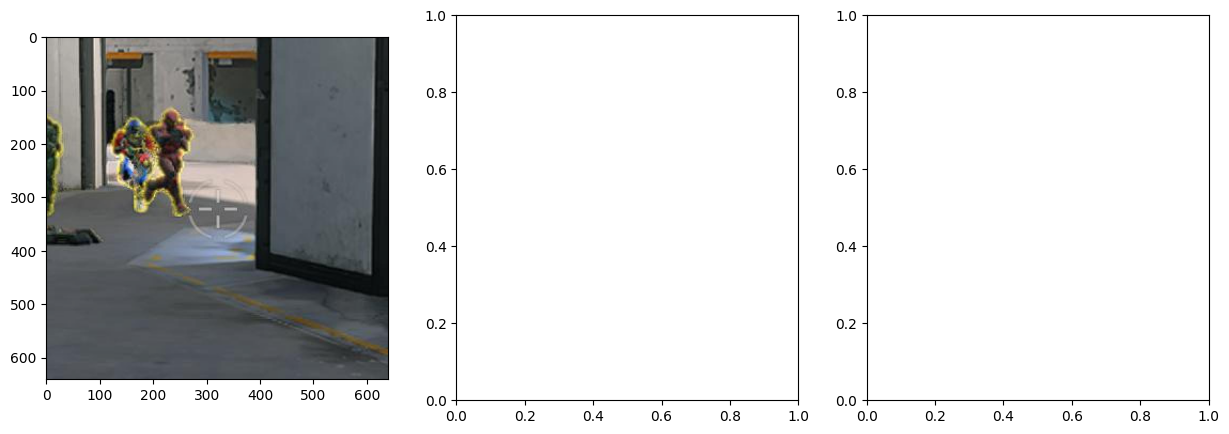

In [110]:
from torchmetrics.detection import MeanAveragePrecision
import matplotlib.patches as patches
@torch.no_grad()
def calculate_map(model, dataloader, device, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8):
    """
    Рассчитывает mAP модели на валидационном датасете.
    """
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    
    for images, targets in tqdm(dataloader, desc="Calculating mAP", leave=False):
        images = images.to(device)
        
        # Получаем предсказания модели
        outputs = model(images)
        bboxes, confidences, cls_probs = outputs
        
        # Фильтруем предсказания
        predictions = filter_predictions(
            bboxes, confidences, cls_probs, 
            score_threshold=score_threshold, 
            nms_threshold=nms_threshold,
            max_boxes_per_cls=max_boxes_per_cls
        )
        
        # Преобразуем targets в нужный формат
        formatted_targets = []
        for target in targets:
            boxes = target['boxes'].cpu()
            labels = target['labels'].cpu()
            
            # Проверяем, есть ли боксы
            if len(boxes) == 0:
                # Нет GT боксов на этом изображении
                formatted_targets.append({
                    'boxes': torch.zeros((0, 4)),
                    'labels': torch.zeros(0, dtype=torch.long),
                    'image_id': torch.tensor([target.get('image_id', 0)])
                })
                continue
            
            # Проверяем размерность boxes
            if boxes.dim() == 1:
                boxes = boxes.unsqueeze(0)
            
            # Конвертируем из xywh в xyxy (формат из датасета)
            boxes_xyxy = boxes.clone()
            boxes_xyxy[:, 2] = boxes[:, 0] + boxes[:, 2]  # x_max = x_min + w
            boxes_xyxy[:, 3] = boxes[:, 1] + boxes[:, 3]  # y_max = y_min + h
            
            formatted_targets.append({
                'boxes': boxes_xyxy,
                'labels': labels,
                'image_id': torch.tensor([target.get('image_id', 0)])
            })
        
        metric.update(predictions, formatted_targets)
    
    results = metric.compute()
    return {
        'map': results['map'].item(),
        'map_50': results['map_50'].item(),
        'map_75': results['map_75'].item(),
        'map_small': results['map_small'].item(),
        'map_medium': results['map_medium'].item(),
        'map_large': results['map_large'].item()
    }


def filter_predictions(bboxes, confidences, cls_probs, score_threshold=0.1, nms_threshold=0.5, max_boxes_per_cls=8):
    """
    Фильтрует предсказания с помощью NMS.
    """
    all_final_scores = confidences[:, :, None] * cls_probs
    num_classes = cls_probs.shape[-1]
    final_predictions = []
    
    for boxes, final_scores in zip(bboxes, all_final_scores):
        preds = {"boxes": [], "labels": [], "scores": []}
        
        # Проверяем, есть ли предсказания
        if len(boxes) == 0:
            final_predictions.append({
                'boxes': torch.zeros((0, 4)),
                'labels': torch.zeros(0, dtype=torch.long),
                'scores': torch.zeros(0)
            })
            continue
        
        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]
            keep_ixs = cls_scores > score_threshold
            
            if keep_ixs.sum() == 0:
                continue
                
            cls_boxes = boxes[keep_ixs]
            cls_scores = cls_scores[keep_ixs]
            
            if len(cls_boxes) > max_boxes_per_cls:
                pos = torch.argsort(cls_scores, descending=True)
                cls_boxes = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]
            
            # Конвертируем из xywh в xyxy для NMS
            boxes_xyxy = cls_boxes.clone()
            boxes_xyxy[:, 2] = cls_boxes[:, 0] + cls_boxes[:, 2]
            boxes_xyxy[:, 3] = cls_boxes[:, 1] + cls_boxes[:, 3]
            
            pred_ixs = nms(boxes_xyxy, cls_scores, nms_threshold)
            
            for ix in pred_ixs:
                preds["boxes"].append(cls_boxes[ix].cpu())
                preds["labels"].append(torch.tensor(cls))
                preds["scores"].append(cls_scores[ix].cpu())
        
        # Конвертируем в тензоры
        if preds["boxes"]:
            preds["boxes"] = torch.stack(preds["boxes"])
            preds["labels"] = torch.stack(preds["labels"])
            preds["scores"] = torch.stack(preds["scores"])
        else:
            preds["boxes"] = torch.zeros((0, 4))
            preds["labels"] = torch.zeros(0, dtype=torch.long)
            preds["scores"] = torch.zeros(0)
        
        final_predictions.append(preds)
    
    return final_predictions


def visualize_predictions(model, dataset, device, num_images=5, score_threshold=0.3, nms_threshold=0.5):
    """
    Визуализирует предсказания модели на нескольких изображениях.
    """
    model.eval()
    
    # Выбираем случайные индексы
    indices = np.random.choice(len(dataset), min(num_images, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(1, len(indices), figsize=(5*len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    
    for idx, ax in zip(indices, axes):
        image, target = dataset[idx]
        
        # Денормализуем изображение
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        original_image = image * std + mean
        original_image = torch.clamp(original_image, 0, 1)
        
        img_np = original_image.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np)
        
        # Получаем предсказания
        with torch.no_grad():
            image_batch = image.unsqueeze(0).to(device)
            outputs = model(image_batch)
            bboxes, confidences, cls_probs = outputs
            
            predictions = filter_predictions(
                bboxes, confidences, cls_probs,
                score_threshold=score_threshold,
                nms_threshold=nms_threshold,
                max_boxes_per_cls=10
            )[0]
        
        # Рисуем GT боксы (в формате xywh)
        gt_boxes = target['boxes'].cpu().numpy()
        gt_labels = target['labels'].cpu().numpy()
        
        if len(gt_boxes) > 0:
            if gt_boxes.ndim == 1 and len(gt_boxes) == 4:
                gt_boxes = gt_boxes.reshape(1, -1)
            
            for box, label in zip(gt_boxes, gt_labels):
                if len(box) == 4:
                    x, y, w, h = box
                    rect = patches.Rectangle(
                        (x, y), w, h, linewidth=2, 
                        edgecolor='green', facecolor='none', linestyle='-'
                    )
                    ax.add_patch(rect)
                    ax.text(x, y-5, f'GT: {label}', fontsize=8, color='green', weight='bold')
        
        # Рисуем предсказания
        if len(predictions['boxes']) > 0:
            pred_boxes = predictions['boxes'].cpu().numpy()
            pred_labels = predictions['labels'].cpu().numpy()
            pred_scores = predictions['scores'].cpu().numpy()
            
            for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
                if len(box) == 4:
                    x, y, w, h = box
                    color = COLORS[label % len(COLORS)]
                    color_rgb = (color[0]/255, color[1]/255, color[2]/255)
                    rect = patches.Rectangle(
                        (x, y), w, h, linewidth=2,
                        edgecolor=color_rgb, facecolor='none', linestyle='--'
                    )
                    ax.add_patch(rect)
                    ax.text(x, y+h+5, f'Pred {label}: {score:.2f}', 
                           fontsize=8, color=color_rgb, weight='bold')
        
        ax.set_title(f'Image {idx}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

import matplotlib.patches as patches
# Пример использования
print("Calculating mAP on test set...")
map_metrics = calculate_map(
    model, test_dataloader, device,
    score_threshold=0.1, nms_threshold=0.5
)

print(f"\n{'='*40}")
print(f"mAP (0.5:0.95): {map_metrics['map']:.4f}")
print(f"mAP@0.5: {map_metrics['map_50']:.4f}")
print(f"mAP@0.75: {map_metrics['map_75']:.4f}")
print(f"{'='*40}")

# Визуализация предсказаний
print("\nVisualizing predictions...")
visualize_predictions(model, test_dataset, device, num_images=3, score_threshold=0.3)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Цвета для разных классов (BGR формат для opencv)
COLORS = [
    (255, 0, 0),    # Красный - класс 0
    (0, 255, 0),    # Зеленый - класс 1
    (0, 0, 255),    # Синий - класс 2
    (255, 255, 0),  # Желтый - класс 3
    (255, 0, 255),  # Пурпурный - класс 4
    (0, 255, 255)   # Голубой - класс 5
]

CLASS_NAMES = {
    0: 'Class 0',
    1: 'Class 1', 
    2: 'Class 2',
    3: 'Class 3'
}


def visualize_predictions(model, dataset, device, num_images=5, score_threshold=0.3, nms_threshold=0.5):
    """
    Визуализирует предсказания модели на нескольких изображениях.
    
    Параметры:
    model - модель детектор
    dataset - датасет с изображениями и GT
    device - устройство
    num_images - количество изображений для визуализации
    score_threshold - порог уверенности
    nms_threshold - порог NMS
    """
    model.eval()
    
    # Выбираем случайные индексы
    indices = np.random.choice(len(dataset), min(num_images, len(dataset)), replace=False)
    
    fig, axes = plt.subplots(1, len(indices), figsize=(5*len(indices), 5))
    if len(indices) == 1:
        axes = [axes]
    
    for idx, ax in zip(indices, axes):
        image, target = dataset[idx]
        original_image = image.clone()
        
        # Нормализуем обратно для визуализации
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        original_image = original_image * std + mean
        original_image = torch.clamp(original_image, 0, 1)
        
        # Переводим в numpy для отображения
        img_np = original_image.permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np)
        
        # Получаем предсказания
        with torch.no_grad():
            image_batch = image.unsqueeze(0).to(device)
            outputs = model(image_batch)
            bboxes, confidences, cls_probs = outputs
            
            # Фильтруем предсказания
            predictions = filter_predictions(
                bboxes, confidences, cls_probs,
                score_threshold=score_threshold,
                nms_threshold=nms_threshold,
                max_boxes_per_cls=10
            )[0]
        
        # Рисуем GT боксы (зеленые)
        gt_boxes = target['boxes'].cpu().numpy()
        gt_labels = target['labels'].cpu().numpy()
        
        for box, label in zip(gt_boxes, gt_labels):
            # Конвертируем из xywh в xyxy если нужно
            if len(box) == 4:
                x, y, w, h = box
                rect = patches.Rectangle(
                    (x, y), w, h, linewidth=2, 
                    edgecolor='green', facecolor='none', linestyle='-'
                )
                ax.add_patch(rect)
                ax.text(x, y-5, f'GT: {CLASS_NAMES.get(label, label)}', 
                       fontsize=8, color='green', weight='bold')
        
        # Рисуем предсказанные боксы (красные)
        if len(predictions['boxes']) > 0:
            pred_boxes = predictions['boxes'].cpu().numpy()
            pred_labels = predictions['labels'].cpu().numpy()
            pred_scores = predictions['scores'].cpu().numpy()
            
            for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
                if len(box) == 4:
                    x, y, w, h = box
                    color = COLORS[label % len(COLORS)]
                    # Конвертируем RGB в формат для matplotlib
                    color_rgb = (color[0]/255, color[1]/255, color[2]/255)
                    rect = patches.Rectangle(
                        (x, y), w, h, linewidth=2,
                        edgecolor=color_rgb, facecolor='none', linestyle='--'
                    )
                    ax.add_patch(rect)
                    ax.text(x, y+h+5, f'{CLASS_NAMES.get(label, label)}: {score:.2f}', 
                           fontsize=8, color=color_rgb, weight='bold')
        
        ax.set_title(f'Image {idx}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


def visualize_single_prediction(model, image_tensor, device, score_threshold=0.3, nms_threshold=0.5, save_path=None):
    """
    Визуализирует предсказание для одного изображения.
    
    Параметры:
    model - модель детектор
    image_tensor - тензор изображения (C, H, W)
    device - устройство
    score_threshold - порог уверенности
    nms_threshold - порог NMS
    save_path - путь для сохранения изображения (опционально)
    """
    model.eval()
    
    # Нормализуем обратно для визуализации
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    original_image = image_tensor.clone()
    original_image = original_image * std + mean
    original_image = torch.clamp(original_image, 0, 1)
    
    img_np = original_image.permute(1, 2, 0).cpu().numpy()
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img_np)
    
    # Получаем предсказания
    with torch.no_grad():
        image_batch = image_tensor.unsqueeze(0).to(device)
        outputs = model(image_batch)
        bboxes, confidences, cls_probs = outputs
        
        predictions = filter_predictions(
            bboxes, confidences, cls_probs,
            score_threshold=score_threshold,
            nms_threshold=nms_threshold,
            max_boxes_per_cls=10
        )[0]
    
    # Рисуем предсказания
    if len(predictions['boxes']) > 0:
        pred_boxes = predictions['boxes'].cpu().numpy()
        pred_labels = predictions['labels'].cpu().numpy()
        pred_scores = predictions['scores'].cpu().numpy()
        
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            if len(box) == 4:
                x, y, w, h = box
                color = COLORS[label % len(COLORS)]
                color_rgb = (color[0]/255, color[1]/255, color[2]/255)
                
                rect = patches.Rectangle(
                    (x, y), w, h, linewidth=2,
                    edgecolor=color_rgb, facecolor='none'
                )
                plt.gca().add_patch(rect)
                plt.text(x, y-5, f'{CLASS_NAMES.get(label, label)}: {score:.2f}', 
                        fontsize=10, color=color_rgb, weight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    plt.axis('off')
    plt.title('Model Predictions')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()


def plot_map_curves(val_metrics_history):
    """
    Визуализирует графики mAP в процессе обучения.
    
    Параметры:
    val_metrics_history - список словарей с метриками mAP
    """
    if not val_metrics_history:
        print("No metrics history available")
        return
    
    epochs = range(1, len(val_metrics_history) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # График mAP
    plt.subplot(1, 2, 1)
    maps = [m['map'] for m in val_metrics_history]
    maps_50 = [m['map_50'] for m in val_metrics_history]
    maps_75 = [m['map_75'] for m in val_metrics_history]
    
    plt.plot(epochs, maps, 'b-o', label='mAP (0.5:0.95)', linewidth=2)
    plt.plot(epochs, maps_50, 'g-s', label='mAP@0.5', linewidth=2)
    plt.plot(epochs, maps_75, 'r-^', label='mAP@0.75', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('mAP', fontsize=12)
    plt.title('mAP Curves', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # График mAP по размерам объектов
    plt.subplot(1, 2, 2)
    map_small = [m['map_small'] for m in val_metrics_history]
    map_medium = [m['map_medium'] for m in val_metrics_history]
    map_large = [m['map_large'] for m in val_metrics_history]
    
    plt.plot(epochs, map_small, 'y--o', label='Small Objects', linewidth=2)
    plt.plot(epochs, map_medium, 'c--s', label='Medium Objects', linewidth=2)
    plt.plot(epochs, map_large, 'm--^', label='Large Objects', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('mAP', fontsize=12)
    plt.title('mAP by Object Size', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Calculating mAP:   0%|          | 0/34 [00:00<?, ?it/s]

mAP (0.5:0.95): 0.0000
mAP@0.5: 0.0000
mAP@0.75: 0.0000


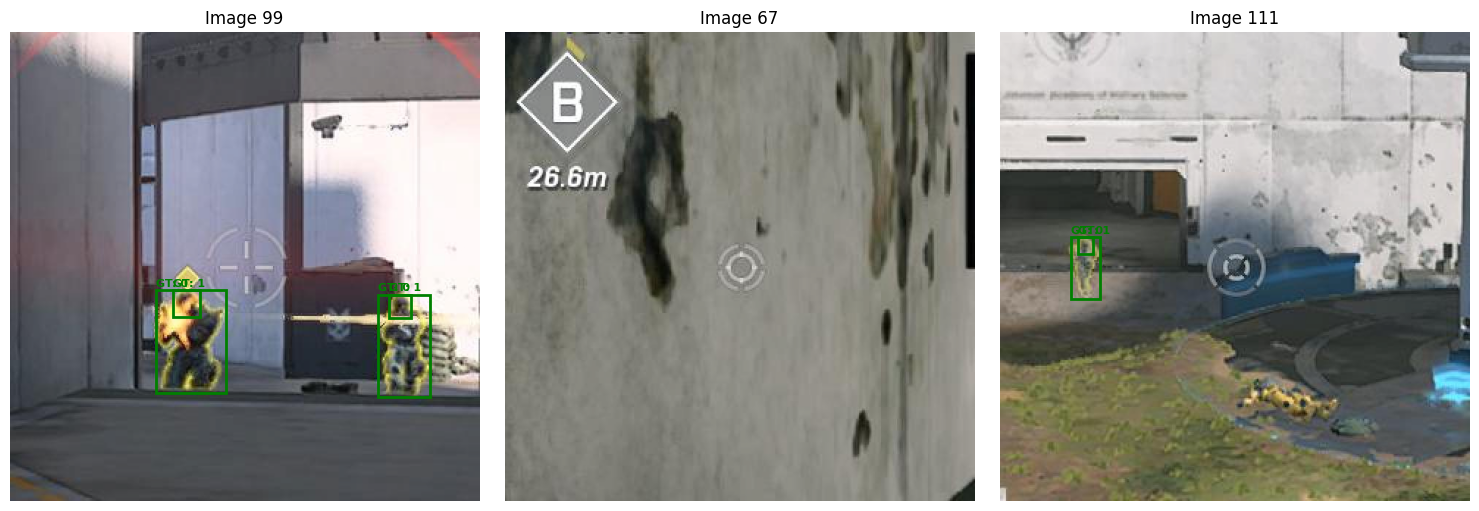

In [112]:

# После обучения модели
# Рассчитываем mAP на тестовом датасете
map_metrics = calculate_map(
    model, test_dataloader, device,
    score_threshold=0.1, nms_threshold=0.5
)

print(f"mAP (0.5:0.95): {map_metrics['map']:.4f}")
print(f"mAP@0.5: {map_metrics['map_50']:.4f}")
print(f"mAP@0.75: {map_metrics['map_75']:.4f}")

# Визуализируем предсказания
visualize_predictions(model, test_dataset, device, num_images=3, score_threshold=0.3)